In [1]:
# Iris Species Classification using Decision Tree

# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Ensure results directory exists
os.makedirs("../results", exist_ok=True)

In [3]:
# Step 2: Load dataset
df = pd.read_csv("../datasets/iris.csv")
print("✅ Dataset loaded successfully!")
print(df.head())


✅ Dataset loaded successfully!
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [4]:
# Step 3: Handle missing values (for demonstration)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [7]:
# Step 4: Encode labels (corrected column name)
label_encoder = LabelEncoder()
df["Species"] = label_encoder.fit_transform(df["Species"])



In [8]:
# Step 5: Split data
X = df.drop(["Id", "Species"], axis=1)
y = df["Species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Step 6: Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [10]:
# Step 7: Predictions
y_pred = model.predict(X_test)

In [12]:
# Step 8: Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

print(f"\n📊 Evaluation Metrics:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")


📊 Evaluation Metrics:
Accuracy: 1.000
Precision: 1.000
Recall: 1.000


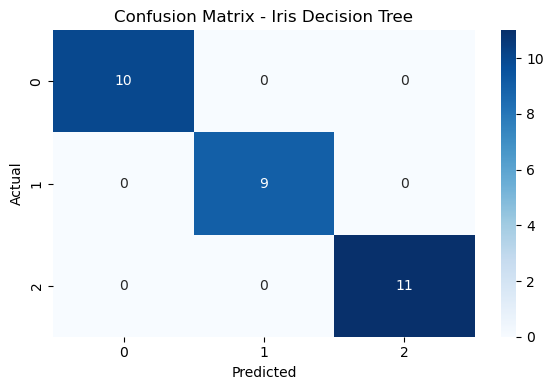

In [13]:
# Step 9: Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Iris Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../results/iris_confusion_matrix.png")
plt.show()

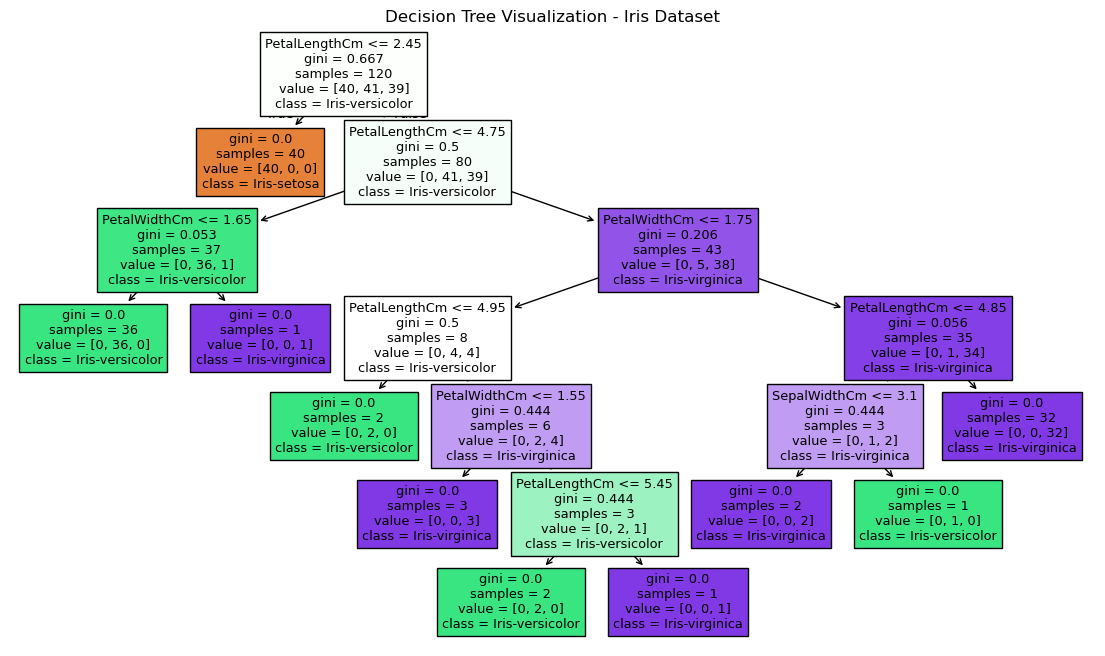

In [14]:
# Step 10: Visualize the decision tree
plt.figure(figsize=(14, 8))
plot_tree(model, feature_names=X.columns, class_names=label_encoder.classes_, filled=True)
plt.title("Decision Tree Visualization - Iris Dataset")
plt.savefig("../results/iris_decision_tree.png")
plt.show()